# The human insula is extensively recruited during human speech

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [6]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

'notebook'

# Fig 1: Whole brain electrodes map to the pial surface

In [7]:
task = [
    'PhonemeSequence',
    'SentenceRep',
    'LexicalDelay',
    'LexicalNoDelay',
    'PictureNaming',
]
ref='bipolar'

stats_paths = []
stats_paths.extend(
    BIDSPath(
        root=f'../results/{t}({ref})',
        datatype='HGA',
        suffix='coord',
        check=False,
    ).match()
    for t in task
)

stats_paths = np.concatenate(stats_paths).tolist()

coords = []
for path in tqdm(stats_paths):
    df = pd.read_csv(path)
    coords.append(df)
    
coords = pd.concat(coords)

# rename INS to 'Insula'
coords.loc[coords.roi == 'INS', 'roi'] = 'Insula'

# combine HG to STG
coords.loc[coords.roi == 'HG', 'roi'] = 'STG'

# rename CG to Cingulate cortex
coords.loc[coords.roi == 'PrG', 'roi'] = 'SMC'
coords.loc[coords.roi == 'PoG', 'roi'] = 'SMC'
coords.loc[coords.roi == 'Subcentral', 'roi'] = 'SMC'

coords.head()

100%|██████████| 911/911 [00:31<00:00, 29.01it/s]


,channel,x,y,z,HGA,significant,subject,task,band,description,phase,label,roi,hemi
0,D0019_ROG1-2,20.731562,-95.433053,-4.406237,-0.041696,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R
1,D0019_ROG2-3,18.712896,-94.417750,6.523434,0.027467,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R
2,D0019_ROG3-4,17.039880,-94.822626,17.317047,0.047800,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R
3,D0019_ROG4-5,16.298644,-91.860079,29.446276,0.044848,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_G_occipital_sup,sOccG,R
4,D0019_ROG5-6,13.397947,-84.402838,39.447554,0.003595,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R


Reading labels from parcellation...


   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


2026-01-12 10:11:05.793 (  82.066s) [    7FD6F22C4440]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-12 10:11:06.623 (  82.895s) [    7FD6F22C4440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x6aa1a80): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-12 10:11:07.011 (  83.284s) [    7FD6F22C4440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x6f78a10): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D en

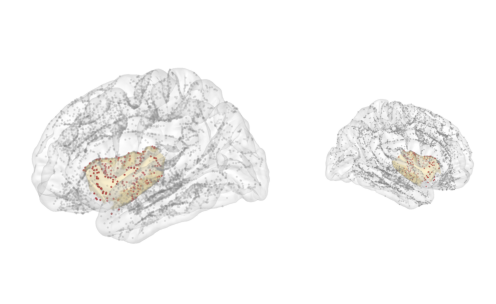

In [ ]:
coords_unique = coords.drop_duplicates(subset=['channel'])

import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

cord = coords_unique[['x', 'y', 'z']].values
insula_mask = coords_unique['roi'].eq('Insula').values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)

electrode_color = 'gray'
insula_electrode_color = red

if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_is_insula = insula_mask[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_projected_coords = lh_coords_pial[lh_indices]

    valid_mask = np.zeros(len(lh_cord), dtype=bool)
    for i, idx in enumerate(lh_indices):
        for lab in labels:
            if lab.hemi == 'lh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~lh_is_insula)
        insula_only = valid_mask & (lh_is_insula)

        if non_insula.any():
            cloud = pv.PolyData(lh_projected_coords[non_insula])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.3,
            )

        if insula_only.any():
            cloud = pv.PolyData(lh_projected_coords[insula_only])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=insula_electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.9,
            )

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_is_insula = insula_mask[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_projected_coords = rh_coords_pial[rh_indices]

    valid_mask = np.zeros(len(rh_cord), dtype=bool)
    for i, idx in enumerate(rh_indices):
        for lab in labels:
            if lab.hemi == 'rh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~rh_is_insula)
        insula_only = valid_mask & (rh_is_insula)

        if non_insula.any():
            cloud = pv.PolyData(rh_projected_coords[non_insula])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.5,
            )

        if insula_only.any():
            cloud = pv.PolyData(rh_projected_coords[insula_only])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=10,
                color=insula_electrode_color,
                lighting=False,
                smooth_shading=False,
                opacity=0.9,
            )

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [3, 1]})
plt.subplots_adjust(wspace=-0.5)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.show()

# Plot Anterioro-posterior insula electrodes

In [9]:
# Insula region classification function and visualization
def classify_insula_ap(coords_df, y_threshold=0):
    """
    Classify insula electrodes into AIC (anterior insula cortex) and PIC (posterior insula cortex)
    
    Classification scheme:
    AIC (red team): 
      - All G_insular_short (regardless of coordinates)
      - All S_circular_insula_ant (regardless of coordinates)  
      - All S_circular_insula_sup with Y > 0
      - All S_circular_insula_inf with Y > 0
    
    PIC (blue team):
      - All G_Ins_lg_and_S_cent_ins (regardless of coordinates)
      - All S_circular_insula_sup with Y <= 0
      - All S_circular_insula_inf with Y <= 0
    """
    # Copy data to avoid modifying original data
    coords_classified = coords_df.copy()
    
    # Initialize new classification
    coords_classified['insula_region'] = coords_classified['roi']
    
    # Only process insula electrodes
    insula_mask = coords_classified['roi'] == 'Insula'
    
    # AIC classification conditions
    aic_conditions = (
        (coords_classified['label'].str.contains('G_insular_short')) |
        (coords_classified['label'].str.contains('S_circular_insula_ant')) |
        ((coords_classified['label'].str.contains('S_circular_insula_sup')) & (coords_classified['y'] > y_threshold)) |
        ((coords_classified['label'].str.contains('S_circular_insula_inf')) & (coords_classified['y'] > y_threshold))
    )
    
    # PIC classification conditions  
    pic_conditions = (
        (coords_classified['label'].str.contains('G_Ins_lg_and_S_cent_ins')) |
        ((coords_classified['label'].str.contains('S_circular_insula_sup')) & (coords_classified['y'] <= y_threshold)) |
        ((coords_classified['label'].str.contains('S_circular_insula_inf')) & (coords_classified['y'] <= y_threshold))
    )
    
    # Apply classification
    coords_classified.loc[insula_mask & aic_conditions, 'roi'] = 'AIC'
    coords_classified.loc[insula_mask & pic_conditions, 'roi'] = 'PIC'
    
    return coords_classified

# Apply classification function
coords_ap = classify_insula_ap(coords)

# Statistical results
print(f"AIC electrode count: {len(coords_ap[coords_ap['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(coords_ap[coords_ap['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = coords_ap[coords_ap['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
coords_ap.head()

AIC electrode count: 1572
PIC electrode count: 1664


,channel,x,y,z,HGA,significant,subject,task,band,description,phase,label,roi,hemi,insula_region
0,D0019_ROG1-2,20.731562,-95.433053,-4.406237,-0.041696,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R,OPC
1,D0019_ROG2-3,18.712896,-94.417750,6.523434,0.027467,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R,OPC
2,D0019_ROG3-4,17.039880,-94.822626,17.317047,0.047800,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R,Unknown
3,D0019_ROG4-5,16.298644,-91.860079,29.446276,0.044848,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_G_occipital_sup,sOccG,R,sOccG
4,D0019_ROG5-6,13.397947,-84.402838,39.447554,0.003595,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R,Unknown


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-12 10:11:25.275 ( 101.548s) [    7FD6F22C4440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1095ad30): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-12 10:11:25.338 ( 101.610s) [    7FD6F22C4440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1095ad30): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

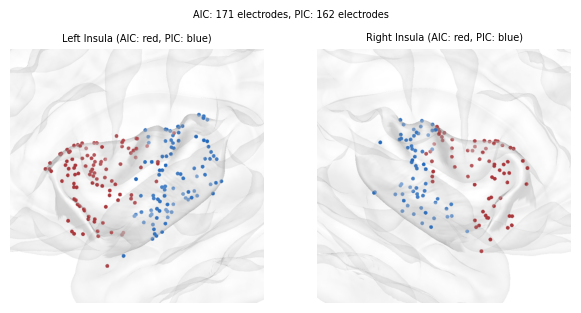

In [10]:
# 3D Brain with AIC/PIC分区显示 - Electrodes projected to surface
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# 获取分区后的insula电极 (使用修改后的roi列)
coords_unique_ap = coords_ap[coords_ap.roi.isin(['AIC', 'PIC'])].drop_duplicates(subset=['channel'])
cord = coords_unique_ap[['x', 'y', 'z']].values
regions = coords_unique_ap['roi'].values

# 分离左右半球电极
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 定义颜色
aic_color = red
pic_color = blue

# 添加左半球电极（投影到表面）
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_regions = regions[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_proj = lh_pial_coords[lh_indices]
    
    # 分别添加AIC和PIC电极
    for region, color in [('AIC', aic_color), ('PIC', pic_color)]:
        region_mask = lh_regions == region
        if region_mask.any():
            cloud = pv.PolyData(lh_cord_proj[region_mask])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=12,
                color=color,
                lighting=False,
            )

# 添加右半球电极（投影到表面）
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_regions = regions[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_proj = rh_pial_coords[rh_indices]
    
    # 分别添加AIC和PIC电极
    for region, color in [('AIC', aic_color), ('PIC', pic_color)]:
        region_mask = rh_regions == region
        if region_mask.any():
            cloud = pv.PolyData(rh_cord_proj[region_mask])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=12,
                color=color,
                lighting=False,
            )

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, 
                   focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, 
                   focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula (AIC: red, PIC: blue)", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula (AIC: red, PIC: blue)", fontsize=fontsize)

# 添加统计信息
aic_count = len(coords_unique_ap[coords_unique_ap['roi'] == 'AIC'])
pic_count = len(coords_unique_ap[coords_unique_ap['roi'] == 'PIC'])
plt.suptitle(f"AIC: {aic_count} electrodes, PIC: {pic_count} electrodes", fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.show()

# TFR on the representation electrode

In [3]:
bids_root = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'

In [12]:
subject = 'D0088'
pickchannels = coords_ap[(coords_ap.subject==subject) &
          (coords_ap.roi=='AIC')].channel.unique().tolist()
print(pickchannels)

['D0088_LAI1-2', 'D0088_LAI5-6', 'D0088_LAI6-7']


In [67]:
# load all three phases
description = 'Repeat'
phases = ['Stimulus', 'Go', 'Response']

tfr_data = {}
stats_data = {}

for phase in phases:
    # Load TFR data
    tfr_path = BIDSPath(
        root=os.path.join(bids_root, 'derivatives', 'tfr'),
        datatype='bipolar',
        suffix='tfr',
        processing=phase,
        extension='.h5',
        check=False
    ).match()[0]
    
    tfr_path = tfr_path.copy().update(subject=subject, description=description)
    tfr_data[phase] = mne.time_frequency.read_tfrs(tfr_path.fpath, verbose=False)
    
    # Load stats data
    stats_path = tfr_path.copy().update(suffix='stats')
    stats = h5py.File(stats_path.fpath, 'r')
    stats_data[phase] = {
        'mask': stats['mask'][()],
        'pvals': stats['pvals'][()]
    }
    stats.close()

i = 2
idx = {phase: tfr_data[phase].ch_names.index(pickchannels[i]) for phase in phases}
tfr_data = {phase: tfr.pick(pickchannels) for phase, tfr in tfr_data.items()}

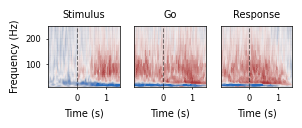

In [89]:
# Plot TFR for all three phases
freqs = tfr_data['Go'].freqs
times = {phase: tfr_data[phase].times for phase in phases}
ch_data = {phase: tfr_data[phase].get_data()[i] for phase in phases}

p_threshold = 0.01
significant = {phase: (stats_data[phase]['pvals'][idx[phase]] < p_threshold) & 
                        (stats_data[phase]['mask'][idx[phase]] > 0) 
               for phase in phases}

# Use consistent color scaling across all phases
all_data = np.concatenate([ch_data[phase] for phase in phases])
vmin, vmax = np.percentile(all_data, [2, 98])

fig, axes = plt.subplots(1, 3, figsize=(8*cm, 2*cm))

plt.subplots_adjust(wspace=0.2)
for ax, phase in zip(axes, phases):
    # Plot TFR
    im = ax.pcolormesh(
        times[phase], freqs, ch_data[phase], 
        shading='gouraud', cmap='vlag', rasterized=True,
        vmin=vmin, vmax=vmax, alpha=0.2
    )
    
    # Add significant regions with overlay method
    if np.any(significant[phase]):
        # Create binary mask
        sig_cluster = np.zeros_like(stats_data[phase]['mask'][idx[phase]])
        sig_cluster[significant[phase]] = 1
        
        # Overlay significant regions with reduced alpha for non-significant
        non_sig_data = ch_data[phase].copy()
        non_sig_data[significant[phase]] = np.nan
        
        ax.pcolormesh(
            times[phase], freqs, non_sig_data,
            shading='gouraud', cmap='vlag', rasterized=True,
            vmin=vmin, vmax=vmax, alpha=0.1
        )
        
        # Plot significant regions fully opaque
        sig_data = ch_data[phase].copy()
        sig_data[~significant[phase]] = np.nan
        
        ax.pcolormesh(
            times[phase], freqs, sig_data,
            shading='gouraud', cmap='vlag', rasterized=True,
            vmin=vmin, vmax=vmax, alpha=1.0
        )
        
        # Add subtle contour boundary
        # ax.contour(times[phase], freqs, sig_cluster,
        #         levels=[0.5], 
        #         colors='black',
        #         alpha=0.3,
        #         linewidths=0.3,
        #         linestyles='-')
    
    ax.set_title(phase, fontsize=7)
    ax.set_ylim(10, 250)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, lw=.75)
    
    # Only show labels on leftmost plot
    if phase == 'Stimulus':
        ax.set_ylabel('Frequency (Hz)', fontsize=7)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.tick_params(labelsize=6, width=.5, length=1.5, which='both')
    plt.setp(ax.spines.values(), linewidth=.5)
    
    # remove y ticks
    if ax != axes[0]:
        ax.set_yticks([])

plt.show()

# Barplot to show the importance

In [91]:
coords.head()

,channel,x,y,z,HGA,significant,subject,task,band,description,phase,label,roi,hemi
0,D0019_ROG1-2,20.731562,-95.433053,-4.406237,-0.041696,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R
1,D0019_ROG2-3,18.712896,-94.417750,6.523434,0.027467,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R
2,D0019_ROG3-4,17.039880,-94.822626,17.317047,0.047800,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R
3,D0019_ROG4-5,16.298644,-91.860079,29.446276,0.044848,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_G_occipital_sup,sOccG,R
4,D0019_ROG5-6,13.397947,-84.402838,39.447554,0.003595,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R


In [121]:
# 只保留 significant 的电极
# sig = coords

description = 'Repeat'
# sig = coords[(coords['significant']) & (coords['description'] == description)]

sig = coords[(coords['description'] == description) & (coords.significant == True) &
             (~coords.roi.isin(['WM', 'Intersection','Unknown'])) 
             & (coords.phase=='Go')
             ]

# 每个 roi、每个 hemi 的电极数（按 channel 去重）
cnt = (
    sig.groupby(['roi', 'hemi'])['channel']
       .nunique()
       .reset_index(name='n_sig')
)
# 变成行=ROI，列=左右脑 的表
plot_df = (
    cnt.pivot(index='roi', columns='hemi', values='n_sig')
       .fillna(0)
)

# 根据你实际的 hemi 值改列名（例如 'L'/'R' 或 'lh'/'rh'）
# 这里假设是 'L' / 'R'
if 'L' in plot_df.columns and 'R' in plot_df.columns:
    left_col, right_col = 'L', 'R'
else:
    # 例如是 'lh' / 'rh'
    left_col, right_col = 'lh', 'rh'

plot_df = plot_df.rename(columns={left_col: 'Left', right_col: 'Right'})
plot_df['total'] = plot_df[['Left', 'Right']].sum(axis=1)

# 按 total 从大到小排序（和你示意图一样从上到下数量递减）
plot_df = plot_df.sort_values('total', ascending=False)
plot_df = plot_df.head(20)
plot_df.head()

hemi,Left,Right,unknown,total
roi,,,,
Insula,46.0,33.0,0.0,79.0
SMC,49.0,29.0,0.0,78.0
STS,38.0,29.0,0.0,67.0
STG,28.0,18.0,0.0,46.0
CG,18.0,18.0,0.0,36.0


In [142]:
# ============================================================
# 按 significant 占比排序 + 多种可视化方式
# ============================================================

description = 'Repeat'
phases = ['Stimulus', 'Go', 'Response']

# 基础筛选（包含所有 phase）
base = coords[
    (coords['description'] == description) &
    (~coords.roi.isin(['WM', 'Intersection', 'Unknown'])) &
    (coords['phase'].isin(phases))
].copy()

# 每个 channel：只要任意 phase significant=True 就算 overall significant
chan_any = (
    base.groupby('channel', as_index=False)
        .agg(
            roi=('roi', 'first'),
            hemi=('hemi', 'first'),
            any_phase_sig=('significant', 'any')  # 关键：任意phase显著即算显著
        )
)

# 然后在 ROI×hemi 上统计
stats_df = (
    chan_any.groupby(['roi', 'hemi'], as_index=False)
            .agg(
                n_sig=('any_phase_sig', 'sum'),
                n_total=('channel', 'nunique')
            )
)

# 计算占比
stats_df['ratio'] = stats_df['n_sig'] / stats_df['n_total']

# 汇总到 roi 级别
roi_stats = (
    stats_df.groupby('roi')
    .agg(
        n_sig_total=('n_sig', 'sum'),
        n_total=('n_total', 'sum')
    )
    .reset_index()
)
roi_stats['ratio'] = roi_stats['n_sig_total'] / roi_stats['n_total']
roi_stats = roi_stats.sort_values('ratio', ascending=False)

# 同时保留左右脑信息用于后续绘图
plot_ratio_df = stats_df.pivot(index='roi', columns='hemi', values='ratio').fillna(0)
plot_count_df = stats_df.pivot(index='roi', columns='hemi', values='n_sig').fillna(0)
plot_total_df = stats_df.pivot(index='roi', columns='hemi', values='n_total').fillna(0)

# 重命名列
for df in [plot_ratio_df, plot_count_df, plot_total_df]:
    if 'L' in df.columns and 'R' in df.columns:
        df.rename(columns={'L': 'Left', 'R': 'Right'}, inplace=True)

picks=['SMC','STG','MFG','SMG',
       'Insula','AG','IFG','STS','MTG',
       'SFG',
      ]
# 先按 picks 过滤，再取 head
roi_stats = roi_stats[roi_stats.roi.isin(picks)]

# 按总占比排序
plot_ratio_df['total_ratio'] = roi_stats.set_index('roi')['ratio']
plot_ratio_df = plot_ratio_df.loc[roi_stats['roi']]
plot_count_df = plot_count_df.reindex(roi_stats['roi'])
plot_total_df = plot_total_df.reindex(roi_stats['roi'])

print("按 significant 占比排序的 ROI:")
display(roi_stats.head(40))

按 significant 占比排序的 ROI:


,roi,n_sig_total,n_total,ratio
22,Insula,136,251,0.541833
45,STG,77,144,0.534722
42,SMC,104,230,0.452174
43,SMG,20,54,0.370370
46,STS,107,307,0.348534
0,AG,10,33,0.303030
17,IFG,24,84,0.285714
27,MFG,27,107,0.252336
29,MTG,27,171,0.157895
40,SFG,12,108,0.111111


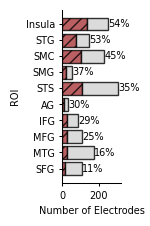

In [145]:
# ============================================================
# 可视化 6: 堆叠条形图 - 显示 significant vs non-significant
# ============================================================

fig, ax = plt.subplots(figsize=(4*cm, 6*cm))

rois = roi_stats['roi'].values
n_sig = roi_stats['n_sig_total'].values
n_total = roi_stats['n_total'].values
n_nonsig = n_total - n_sig

# 堆叠条形图
ax.barh(rois, n_sig, color=red, edgecolor='black', label='Significant', alpha=0.8, height=0.8, hatch='///',)
ax.barh(rois, n_nonsig, left=n_sig, color='lightgray', edgecolor='black', label='Non-significant', alpha=0.8, height=0.8)

# 在条形右侧标注占比
for i, (roi, sig, total) in enumerate(zip(rois, n_sig, n_total)):
    ratio = sig / total * 100
    ax.text(total + 2, roi, f'{ratio:.0f}%', va='center', fontsize=7)


for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
ax.set_xlabel('Number of Electrodes', fontsize=fontsize)
ax.set_ylabel('ROI', fontsize=fontsize)

sns.despine()
ax.invert_yaxis()
# ax.legend(loc='lower right', fontsize=6)
plt.tight_layout()
plt.show()

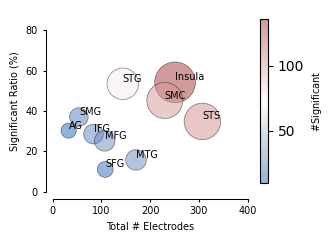

In [152]:
rois = roi_stats['roi'].values
n_total = roi_stats['n_total'].values
ratio_pct = roi_stats['ratio'].values * 100

fig, ax = plt.subplots(figsize=(8*cm, 6*cm))

n_sig = roi_stats['n_sig_total'].values
sizes = (n_sig / max(n_sig.max(), 1)) * 800 + 60

sc = ax.scatter(
    n_total,
    ratio_pct,
    s=sizes,
    c=n_sig,
    cmap='vlag',
    alpha=0.5,
    edgecolor='black',
    linewidth=0.5,
)

for roi, x, y in zip(rois, n_total, ratio_pct):
    ax.text(x, y, roi, fontsize=7, ha='left', va='bottom')

ax.set_xlabel('Total # Electrodes', fontsize=fontsize)
ax.set_ylabel('Significant Ratio (%)', fontsize=fontsize)
ax.set_ylim(0, 90)
ax.set_xlim(0, 400)
sns.despine(offset=5, trim=True)

for ax in fig.axes:
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)

cbar = plt.colorbar(sc, ax=ax, shrink=0.9)
cbar.set_label(r'$\# \mathrm{Significant}$', fontsize=7)

fig.savefig('../img/fig1/fig1_insula_stats.svg', dpi=300, bbox_inches='tight')
plt.show()